# BUSA8001 Programming Task 2  

**Assignment Points**: 100    
**Due Date**: Friday of Week 11 (18 October 2024) at 11:59pm   




---

## About This Assignment
Customer segmentation is the process of dividing customers into groups based on common characteristics so companies can market to each group effectively and appropriately. It can be employed by all types of business, regardless of size, industry and whether they sell online or in person. For example, a small business selling guitars might decide to promote lower-priced products to younger guitarists and higher-priced premium guitars to older musicians based on segment knowledge which tells them that younger musicians have less disposable income than their older counterparts.  

<hr style="width:35%;margin-left:0;"> 

## Task

You are employed by a large travel agency to perform customer segmentation analysis. You are provided with a dataset of 2,000 customers collected through their bookings and interactions with the agency. The dataset includes variables such as customer age, gender, annual income, etc.

Your task is to analyse the data in Python using relevant techniques covered in lectures and identify distinct customer segments within the dataset. You will then compile your results into tables and diagrams and writeup a report of up to **1,000 words** (excluding tables and figures). Ensure your report is informative, intuitive, and easily understandable for management, who may not have a technical background.

Your report should address the questions listed below under the following headings:

1. **Word count** (if missing -5 marks)
    - Include the word count of your report 
2. **Introduction** (10 marks)
    - Describe the problem, explain what you aim to achieve by solving it, outline the approach you will take to address it, and specify the data you will use
3. **Exploratory Data Analysis** (20 marks)
    - Perform basic exploratory data analysis, present and comment on key summary statistics, etc.
    - Provide charts (e.g. histograms, pie charts) where appropriate
4. **Customer Segmentation** (40 marks)
    - Standardise the two numeric variables using StandardScaler
    - Choose the optimal number of customer segments/clusters using the Elbow Method and three appropriately chosen Silhouette Plots
    - After identifying the optimal number of clusters, estimate the clusters using both the K-means++ and Agglomerative Clustering techniques. (Use all variables without applying any dimensionality reduction techniques)
    - Provide a separate table for each clustering technique that contains the cluster centers (for all variables), as well as the number of customers in each cluster
    - Interpret each of the identified clusters (for both clustering techniques) in terms of customer attributes, i.e. profile the clients in each cluster
        - E.g., Cluster 1 may be a cluster of young, single females employed as managers on high incomes and living in large cities
     - Compare the customer segments identified by the two techniques. Do any clusters overlap?
6. **Recommendations** (20 marks)
    - Suggest marketing strategies and techniques that could be used to target customer segements previously identified using the K-means++ method 
7. **Conclusion** (10 marks)
    - A summary of what you have done in the report 
    
---
---


## Assignment Submission   
You will need to submit two files:   

1. A PDF document containing your report for company management submission. Ensure it's comprehensive, including all relevant tables and graphs generated from the Jupyter notebook that you also submit. I suggest drafting the report in Word and then converting it to PDF for submission.
2. Your Jupyter Notebook containing the Python code used in your analysis. Ensure that your code is well-organized, easy to understand, and capable of generating all the outputs included in the report (will be used to verify your analysis presented in the submitted report).

## Marking Criteria

- To receive full marks your solutions must satisfy the following criteria:
    - Provide numerically correct answers;
    - Use Python methods and libraries covered in lectures;
    - Do not include irrelevant material in the report (that you do not discuss);
    - When including tables and charts label them properly;
    - Each included table and chart you include in the report needs to be discussed in text;
    - The report is to be read by marketing managers who may not have the expertise to understand technical terms; 
        - It should be written in clear and easy to understand sentences.
    - Report must contain the word count
    - See Marking Rubric file for details


## Setting the environment

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings 
warnings.filterwarnings("ignore")

## I. Data preperation

In [8]:
# Load the dataset
df = pd.read_csv('data/data.csv')
# Preview the dataset
df.head()

,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size
0,1,1,39,2,130568,1,2
1,0,0,29,1,80315,0,0
2,1,0,35,0,107067,0,0
3,0,1,56,2,214000,1,0
4,1,1,45,2,158138,1,2


In [9]:
# Check the shape of the dataset
df.shape

(2000, 7)

In [10]:
# Check data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           2000 non-null   int64
 1   Marital Status   2000 non-null   int64
 2   Age              2000 non-null   int64
 3   Education        2000 non-null   int64
 4   Income           2000 non-null   int64
 5   Occupation       2000 non-null   int64
 6   Settlement Size  2000 non-null   int64
dtypes: int64(7)
memory usage: 109.5 KB


In [11]:
# Check for missing values
df.isnull().sum()

Gender             0
Marital Status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement Size    0
dtype: int64

## II. Exploratory Data Analysis (EDA) with summary statistics and visualisations

In [13]:
# Summary statistics
df.describe()

,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.60450,0.500500,40.823500,1.456500,137516.196500,0.612500,0.834000
std,0.48908,0.500125,9.455848,0.783846,46184.296588,0.674219,0.967942
min,0.00000,0.000000,20.000000,0.000000,35832.000000,0.000000,0.000000
25%,0.00000,0.000000,33.000000,1.000000,101262.750000,0.000000,0.000000
50%,1.00000,1.000000,40.000000,1.000000,133004.000000,1.000000,0.000000
75%,1.00000,1.000000,48.000000,2.000000,171232.500000,1.000000,2.000000
max,1.00000,1.000000,76.000000,3.000000,309364.000000,2.000000,2.000000


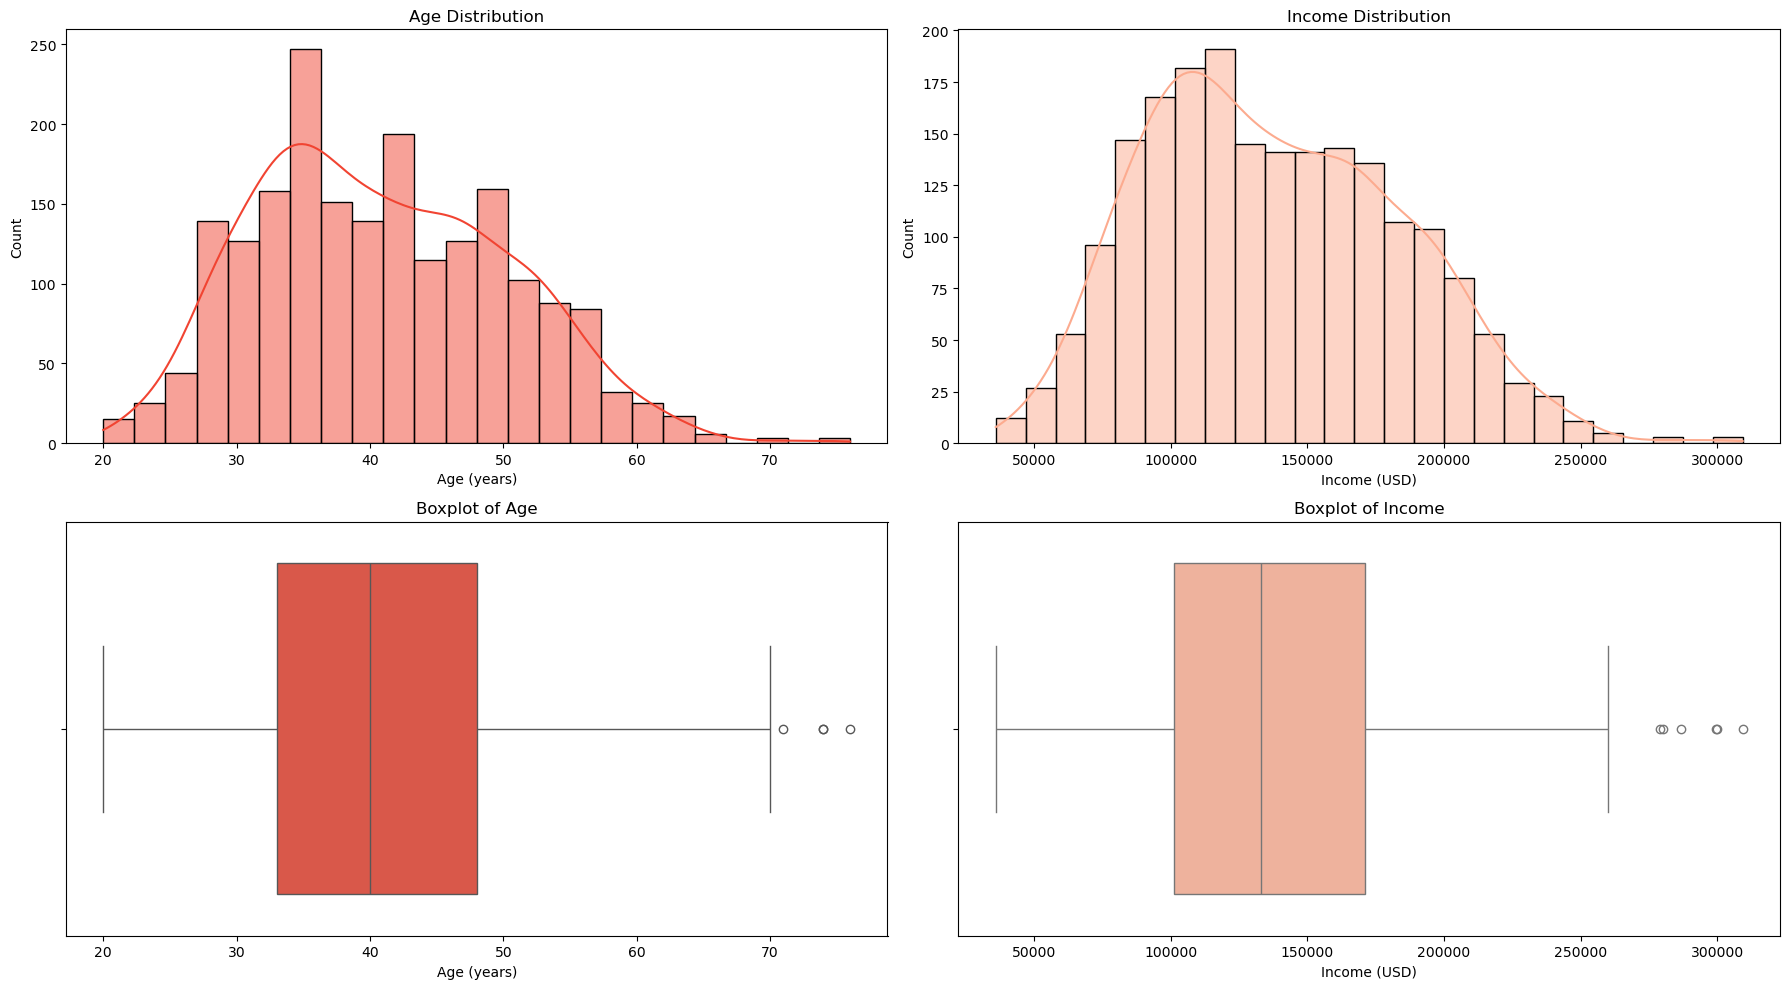

In [14]:
# Define the color map
cmap = cm.get_cmap('Reds') 

# Generate colors from the Reds colormap
age_color = cmap(0.6)  
income_color = cmap(0.3)  

# Set up the overall figure size
plt.figure(figsize=(18, 10))

# Age
    # Age distribution with histogram and KDE
plt.subplot(2, 2, 1)
sns.histplot(df['Age'], kde=True, color=age_color)
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Count')

    # Age distribution with boxplot
plt.subplot(2, 2, 3)
sns.boxplot(x='Age', data=df, color=age_color)
plt.title('Boxplot of Age')
plt.xlabel('Age (years)')

# Income
    # Income distribution with histogram and KDE
plt.subplot(2, 2, 2)
sns.histplot(df['Income'], kde=True, color=income_color)
plt.title('Income Distribution')
plt.xlabel('Income (USD)')
plt.ylabel('Count')

    # Income distribution with boxplot
plt.subplot(2, 2, 4)
sns.boxplot(x='Income', data=df, color=income_color)
plt.title('Boxplot of Income')
plt.xlabel('Income (USD)')

plt.tight_layout()
plt.show()

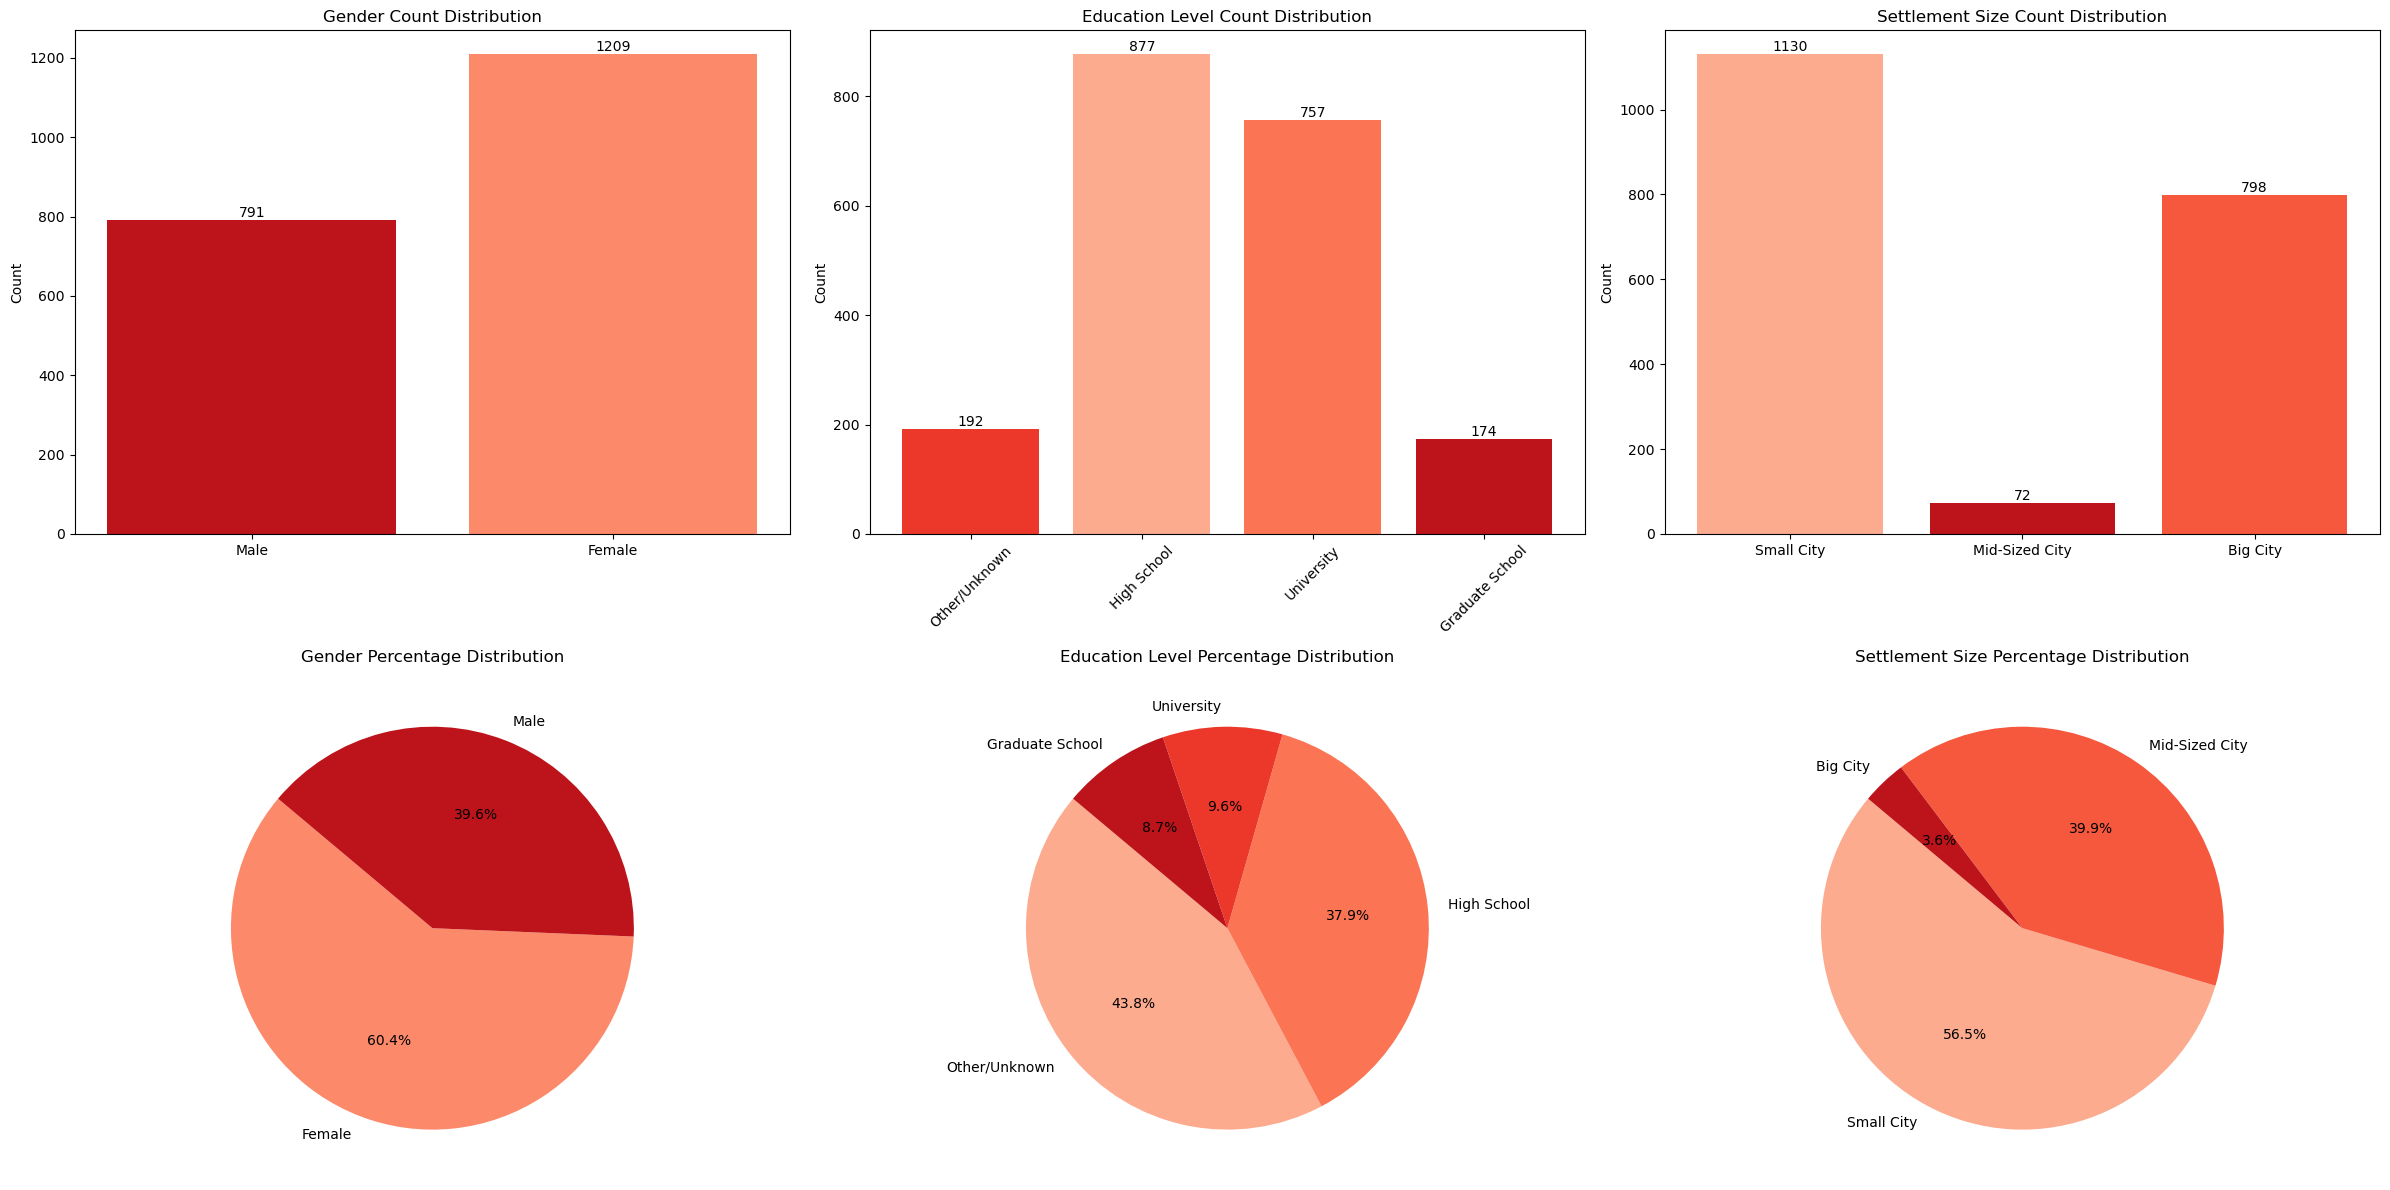

In [15]:
# Set up the overall figure size
plt.figure(figsize=(24, 12))

# Generate shaded colors based on the number of categories
gender_colors = cmap(np.linspace(0.4, 0.8, len(df['Gender'].unique())))
education_colors = cmap(np.linspace(0.3, 0.8, len(df['Education'].unique())))
settlement_colors = cmap(np.linspace(0.3, 0.8, len(df['Settlement Size'].unique())))

# Bar charts for categorical features
# Gender
    # Gender bar chart
plt.subplot(2, 3, 1)
gender_counts = df['Gender'].value_counts()
bars = plt.bar(gender_counts.index, gender_counts, color=gender_colors)
plt.title('Gender Count Distribution')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])

    # Add number labels for Gender
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

# Education
    # Education level bar chart
plt.subplot(2, 3, 2)
education_counts = df['Education'].value_counts()
bars = plt.bar(education_counts.index, education_counts, color=education_colors)
plt.title('Education Level Count Distribution')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Other/Unknown', 'High School', 'University', 'Graduate School'], rotation=45)

    # Add number labels for Education
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

# Settlement size
    # Settlement size bar chart
plt.subplot(2, 3, 3)
settlement_counts = df['Settlement Size'].value_counts()
bars = plt.bar(settlement_counts.index, settlement_counts, color=settlement_colors)
plt.title('Settlement Size Count Distribution')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Small City', 'Mid-Sized City', 'Big City'])

    # Add number labels for Settlement Size
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')


# Pie charts for categorical features
# Gender pie chart
plt.subplot(2, 3, 4)
plt.pie(gender_counts, labels=['Female', 'Male'], autopct='%1.1f%%', colors=gender_colors, startangle=140)
plt.title('Gender Percentage Distribution', pad=10)

# Education level pie chart
plt.subplot(2, 3, 5)
plt.pie(education_counts, labels=['Other/Unknown', 'High School', 'University', 'Graduate School'], autopct='%1.1f%%', colors=education_colors, startangle=140)
plt.title('Education Level Percentage Distribution', pad=10)

# Settlement size pie chart
plt.subplot(2, 3, 6)
plt.pie(settlement_counts, labels=['Small City', 'Mid-Sized City', 'Big City'], autopct='%1.1f%%', colors=settlement_colors, startangle=140)
plt.title('Settlement Size Percentage Distribution', pad=10)

plt.tight_layout()
plt.show()

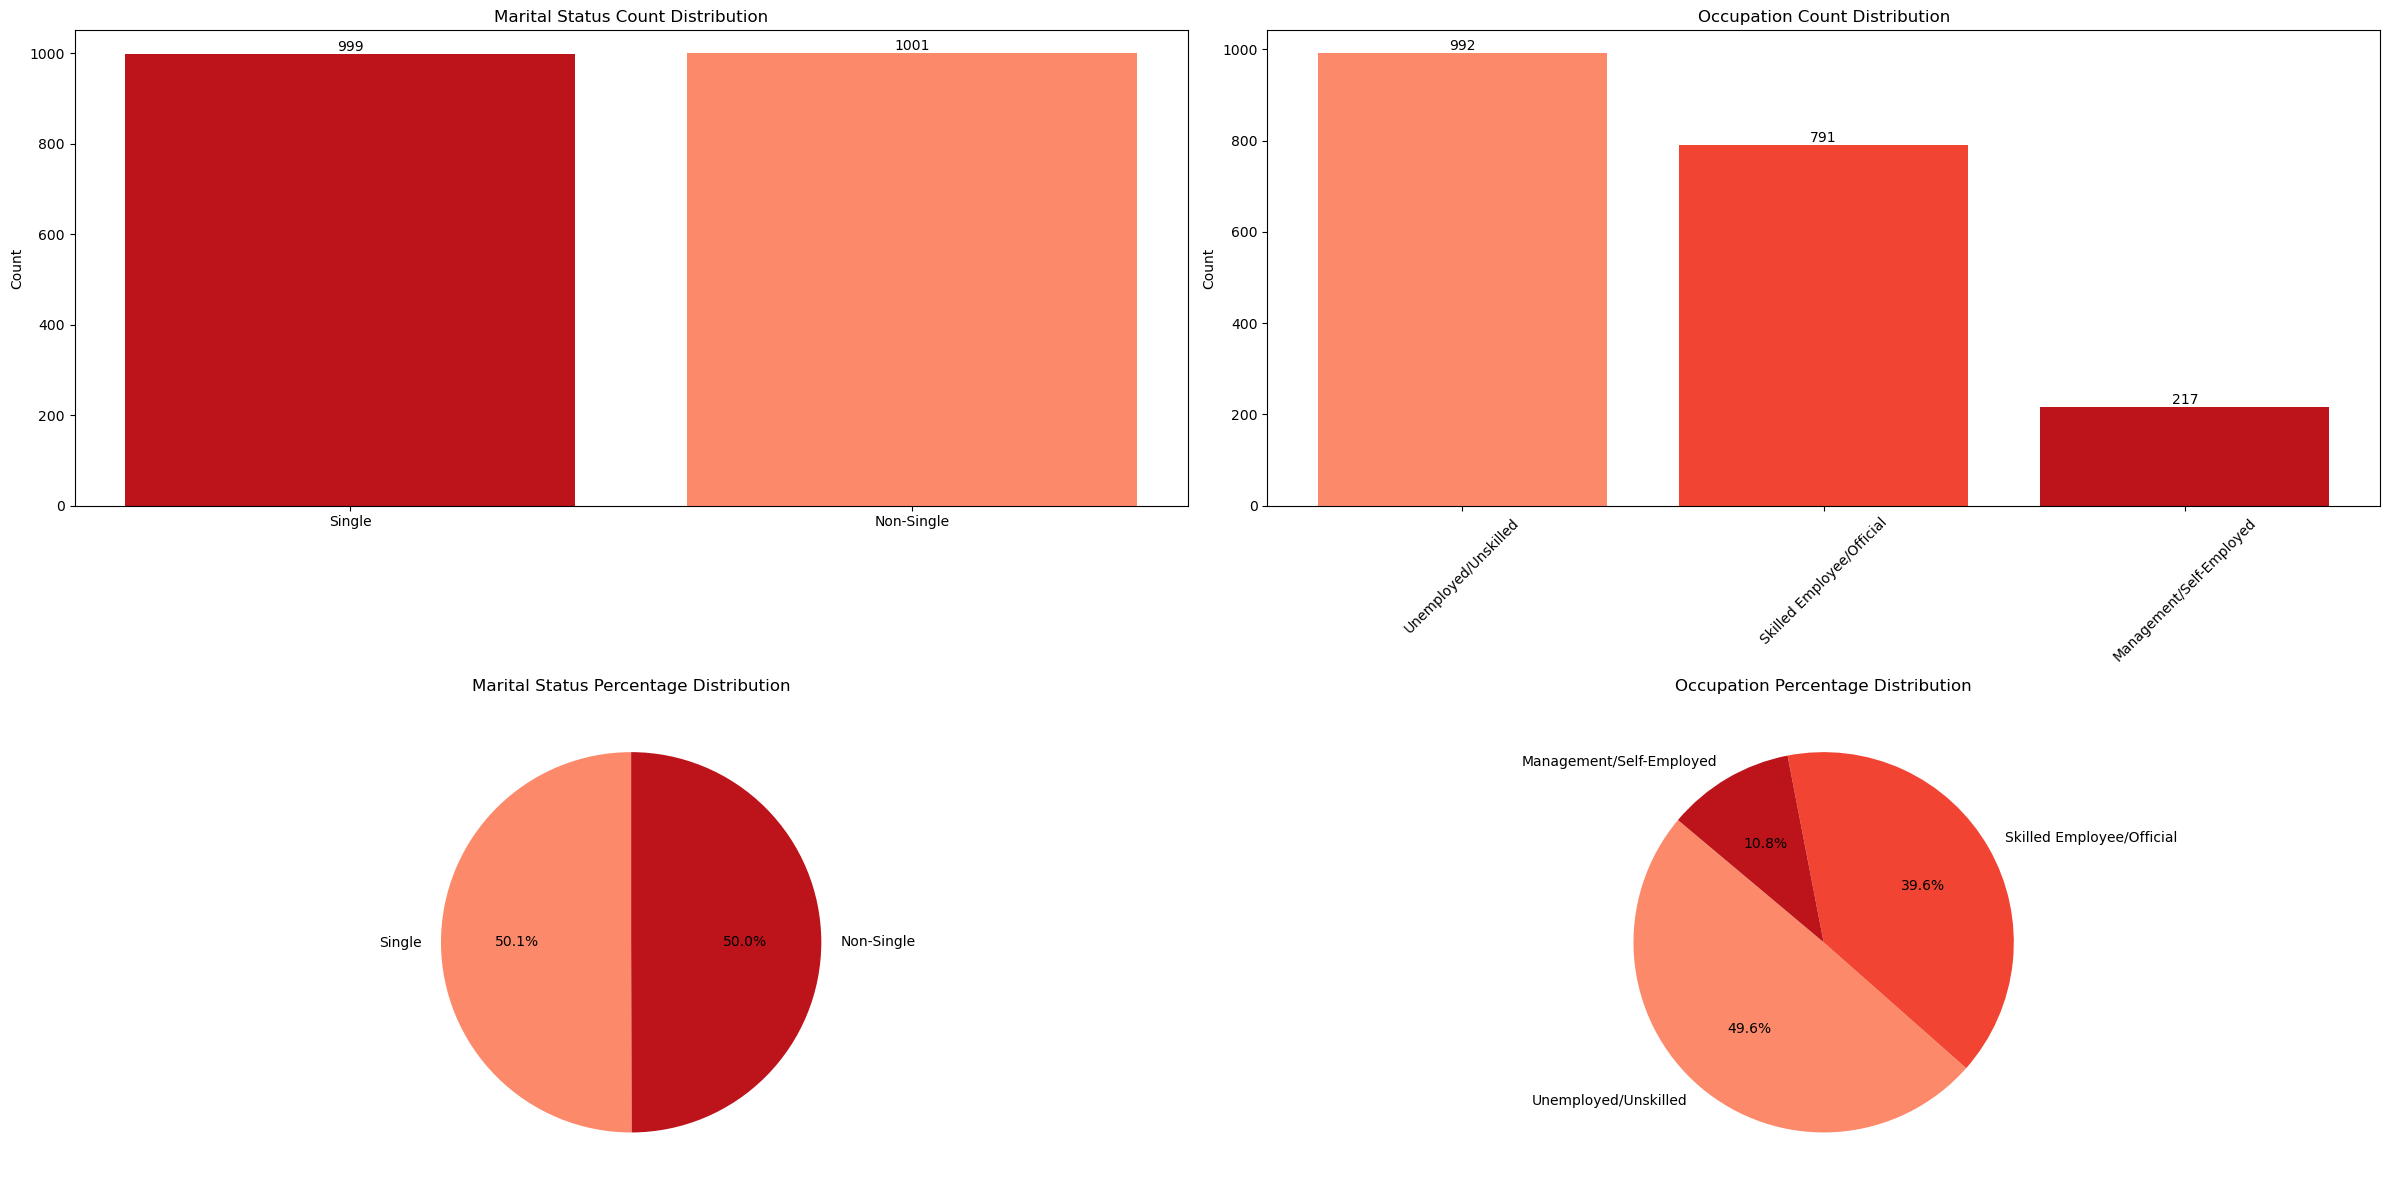

In [16]:
# Set up the overall figure size
plt.figure(figsize=(24, 12))

# Generate shaded colors based on the number of categories
marital_colors = cmap(np.linspace(0.4, 0.8, len(df['Marital Status'].unique())))
occupation_colors = cmap(np.linspace(0.4, 0.8, len(df['Occupation'].unique())))

# Bar charts for categorical features
# Marital
    # Marital Status bar chart
plt.subplot(2, 2, 1)
marital_counts = df['Marital Status'].value_counts()
bars = plt.bar(marital_counts.index, marital_counts, color=marital_colors)
plt.title('Marital Status Count Distribution')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Single', 'Non-Single'])

    # Add number labels for Marital Status
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

# Occupation
    # Occupation bar chart
plt.subplot(2, 2, 2)
occupation_counts = df['Occupation'].value_counts()
bars = plt.bar(occupation_counts.index, occupation_counts, color=occupation_colors)
plt.title('Occupation Count Distribution')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Unemployed/Unskilled', 'Skilled Employee/Official', 'Management/Self-Employed'], rotation=45)

    # Add number labels for Occupation
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

# Pie charts for categorical features
# Marital Status pie chart
plt.subplot(2, 2, 3)
plt.pie(marital_counts, labels=['Single', 'Non-Single'], autopct='%1.1f%%', colors=marital_colors, startangle=90)
plt.title('Marital Status Percentage Distribution', pad=10)

# Occupation pie chart
plt.subplot(2, 2, 4)
plt.pie(occupation_counts, labels=['Unemployed/Unskilled', 'Skilled Employee/Official', 'Management/Self-Employed'], autopct='%1.1f%%', colors=occupation_colors, startangle=140)
plt.title('Occupation Percentage Distribution', pad=10)

plt.tight_layout()
plt.show()

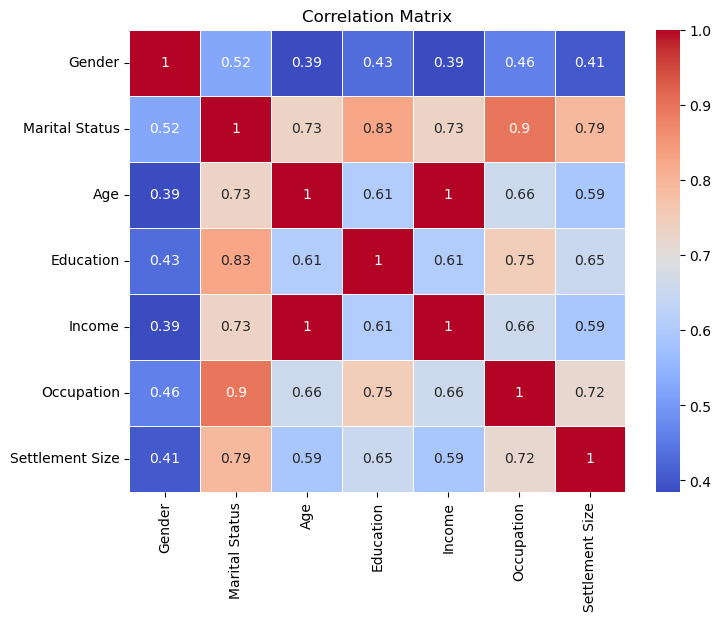

In [17]:
# Generate correlation matrix for the dataset
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()

# Heatmap of the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

## III. Determining Optimal Number of Clusters

In [19]:
# Copy dataframe into df_scaled
df_scaled = df.copy()

# Standardise numeric columns
scaler = StandardScaler()
df_scaled[['Age', 'Income']] = scaler.fit_transform(df[['Age', 'Income']])

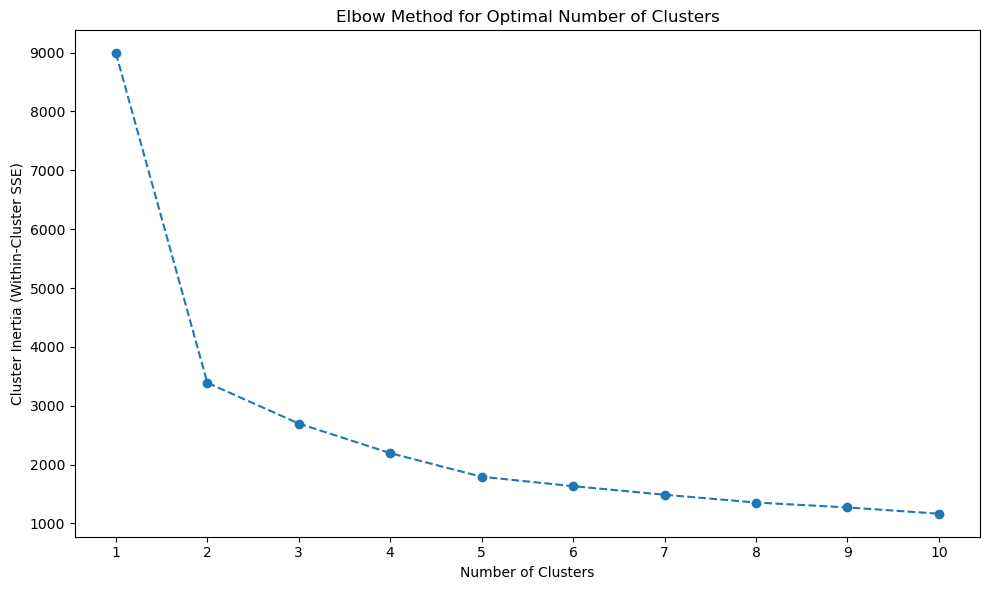

In [20]:
# Choosing the optimal number of clusters using the Elbow Method
inertias = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, 
                init='k-means++', 
                n_init=10, 
                max_iter=300, 
                random_state=0)
    km.fit(df_scaled)
    inertias.append(km.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertias, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Cluster Inertia (Within-Cluster SSE)')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

silhouette_avg: 0.54


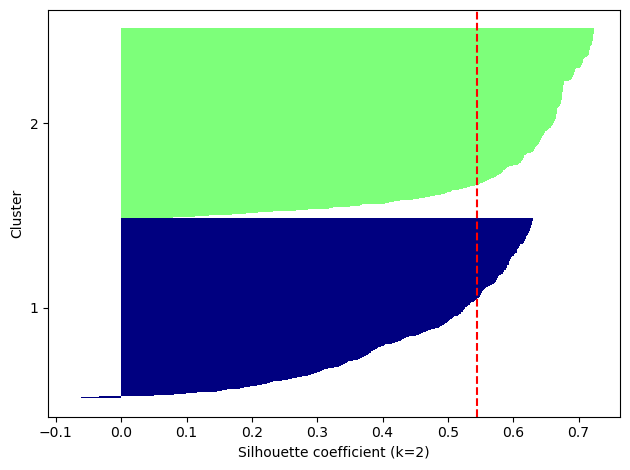

In [21]:
# Run KMeans++ with K=2 
km = KMeans(n_clusters=2,  
            init='k-means++', 
            n_init=10, 
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km_2 = km.fit_predict(df_scaled)
cluster_labels = np.unique(y_km_2)
n_clusters = cluster_labels.shape[0]

silhouette_vals = silhouette_samples(df_scaled, y_km_2, metric='euclidean')

## ------- plotting silhouette values -------

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km_2 == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
    
silhouette_avg = np.mean(silhouette_vals)
print(f'silhouette_avg: {silhouette_avg:.2f}')
plt.axvline(silhouette_avg, color="red", linestyle="--")

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient (k=2)')
plt.tight_layout()
plt.show()

silhouette_avg: 0.43


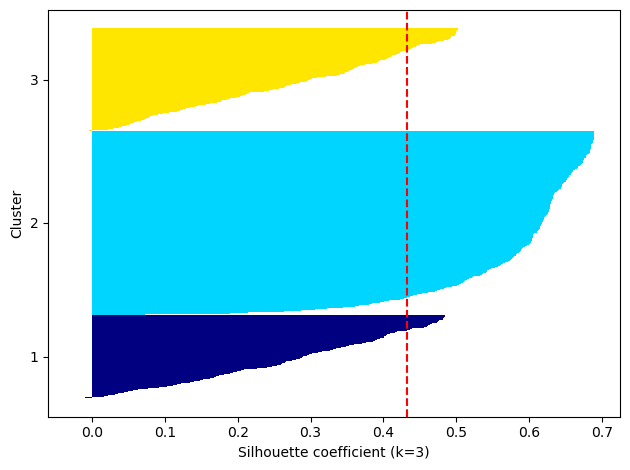

In [22]:
# Run KMeans++ with K=3
km = KMeans(n_clusters=3,  
            init='k-means++', 
            n_init=10, 
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_km_3 = km.fit_predict(df_scaled)
cluster_labels = np.unique(y_km_3)
n_clusters = cluster_labels.shape[0]

silhouette_vals = silhouette_samples(df_scaled, y_km_3, metric='euclidean')

## ------- plotting silhouette values -------

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km_3 == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
    
silhouette_avg = np.mean(silhouette_vals)
print(f'silhouette_avg: {silhouette_avg:.2f}')
plt.axvline(silhouette_avg, color="red", linestyle="--")

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient (k=3)')
plt.tight_layout()
plt.show()

silhouette_avg: 0.45


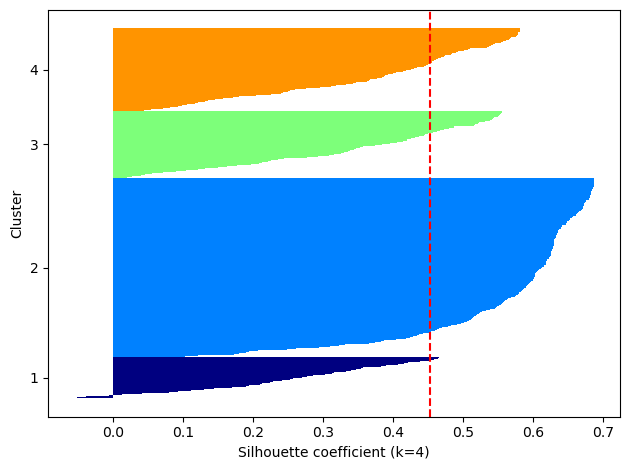

In [23]:
# Run KMeans++ with K=4
km = KMeans(n_clusters=4,  
            init='k-means++', 
            n_init=10, 
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_km_4 = km.fit_predict(df_scaled)
cluster_labels = np.unique(y_km_4)
n_clusters = cluster_labels.shape[0]

silhouette_vals = silhouette_samples(df_scaled, y_km_4, metric='euclidean')

## ------- plotting silhouette values -------

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km_4 == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
    
silhouette_avg = np.mean(silhouette_vals)
print(f'silhouette_avg: {silhouette_avg:.2f}')
plt.axvline(silhouette_avg, color="red", linestyle="--")

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient (k=4)')
plt.tight_layout()
plt.show()

In [24]:
# Scale Age and Income again and then fit into KMeans model
df_selected = df[['Age', 'Income']]  # Select Age and Income for scaling
df_other_features = df.drop(columns=['Age', 'Income'])  # Other features

# Scale Age and Income
scaler = StandardScaler()
df_scaled_age_income = scaler.fit_transform(df_selected)

# Combine the scaled Age and Income with the other features
df_combined = pd.concat([pd.DataFrame(df_scaled_age_income, columns=['Age', 'Income']), df_other_features.reset_index(drop=True)], axis=1)

# Fit the K-means model with 2 clusters
km = KMeans(n_clusters=2,  
            init='k-means++', 
            n_init=10, 
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km_2 = km.fit_predict(df_combined)

# Extract the cluster centers
cluster_centers = km.cluster_centers_

# Count the number of customers in each cluster
cluster_counts = np.bincount(y_km_2)

# Inverse transform the standardized features (Age and Income) back to their original scale
original_cluster_centers = scaler.inverse_transform(cluster_centers[:, :2])

# Create a DataFrame for the original cluster centers with all features
kmeans_cluster_centers = pd.DataFrame(cluster_centers, columns=df_combined.columns)
kmeans_cluster_centers[['Age', 'Income']] = original_cluster_centers

# Add the number of customers in each cluster to the DataFrame
kmeans_cluster_centers['Customer Count'] = cluster_counts

# Re-arrange the columns so that Age and Income are placed at the original positions
kmeans_cluster_centers = kmeans_cluster_centers[['Gender', 'Marital Status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement Size', 'Customer Count']]

# Display the cluster centers with customer counts
print("Kmeans Clustering Summary (k=2)")
display(kmeans_cluster_centers)

Kmeans Clustering Summary (k=2)


,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size,Customer Count
0,0.856410,0.992821,48.174359,2.103590,173443.318974,1.215385,1.636923,976
1,0.364878,0.032195,33.831220,0.840976,103341.616585,0.039024,0.070244,1024


In [25]:
# Feature columns based on the previous analysis
feature_columns = ['Gender', 'Marital Status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement Size']

# Running Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')

# Perform clustering
cluster_labels = agg_clustering.fit_predict(df_scaled[feature_columns])

# Calculate the mean of each feature for each cluster
centers_agg = pd.DataFrame(df_scaled[feature_columns].values, columns=feature_columns).groupby(cluster_labels).mean()

# Inverse transform Age and Income back to their original scale
scaler = StandardScaler()
scaler.fit(df[['Age', 'Income']])  # Fit the scaler on the original Age and Income data
original_age_income_centers = scaler.inverse_transform(centers_agg[['Age', 'Income']])

# Replace the standardised Age and Income values with the inverse-transformed original values
centers_agg[['Age', 'Income']] = original_age_income_centers

# Calculate the number of data points in each cluster
cluster_size = pd.Series(cluster_labels).value_counts().rename_axis('Cluster').reset_index(name='Count')

# Combine the cluster centers and sizes into a single DataFrame
agg_cluster_summary = centers_agg.join(cluster_size.set_index('Cluster'))

# Display the cluster centers with customer counts
print("Agglomerative Clustering Summary (k=2)")
display(agg_cluster_summary)

Agglomerative Clustering Summary (k=2)


,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size,Count
0,0.774721,0.856406,47.080825,1.925193,168085.081685,1.043852,1.384351,1163
1,0.367981,0.005974,32.129032,0.805257,95041.150538,0.013142,0.069295,837
